# EDA: подготовка данных перед Feature Engineering

Ноутбук построен так, чтобы результаты EDA можно было напрямую использовать на следующем этапе:
в конце сохраняются очищенные датасеты (`X_clean_v1`, `X_clean_v2`), группы признаков и сводная
таблица `feature_summary` в папку `artifacts/`

**Структура:**
1. Подготовка и установка
2. Базовая валидация (shapes, ID, target)
3. Типы данных и пропуски
4. Типология признаков (константы, бинарные, low-card, sparse, −1-encoded, skewed)
5. Связь признаков с target (корреляция, биннинг, эффект −1, эффект ненулевого значения)
6. Мультиколлинеарность
7. Стабильность train vs test
8. Итоговая сводка `feature_summary`
9. Cleaning: `X_clean_v1`, `X_clean_v2`
10. Сохранение артефактов для Feature Engineering


## 1. Подготовка и установка 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# ---- Пути ----
DATA_DIR = Path(".")
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

# ---- Роли колонок ----
TARGET = "target"
ID_COL = "index"

# ---- Пороги EDA ----
LOW_CARD_MAX_UNIQUE   = 5      # признак считается low-cardinality, если <= 5 уникальных
HIGH_ZERO_MIN_SHARE   = 0.80   # признак считается sparse, если >= 80% нулей
HIGH_SKEW_MIN_ABS     = 5.0    # признак считается skewed, если |skew| >= 5
MINUS_ONE_MIN_PCT     = 1.0    # -1 считаем значимым, если встречается в >= 1% строк
MINUS_ONE_RATE_DIFF   = 0.002  # минимальный сдвиг target rate для "информативного" -1
HIGH_CORR_PAIR_THRESH = 0.90   # порог для поиска скоррелированных пар
TOP_N_FEATURES        = 20     # сколько top-признаков рассматривать детально


In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")

print("Train shape:", train.shape)
print("Test  shape:", test.shape)
train.head()

Train shape: (247972, 1369)
Test  shape: (106274, 1368)


,index,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,...,feature_1342,feature_1343,feature_1344,feature_1345,feature_1346,feature_1347,feature_1348,feature_1349,feature_1350,feature_1351,feature_1352,feature_1353,feature_1354,feature_1355,feature_1356,feature_1357,feature_1358,feature_1359,feature_1360,feature_1361,feature_1362,feature_1363,feature_1364,feature_1365,feature_1366
0,239134,0.0,0.5,0.5,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.680302,0.767927,0.917902,0.527302,0.428348,0.466657,0.548376,0.815871,0.806104,0.729982,0.247545,0.604350,0.319196,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,1,1,1,1,0
1,234708,0.0,0.5,0.5,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.680302,0.767927,0.917902,0.527302,0.428348,0.466657,0.548376,0.815871,0.806104,0.729982,0.247545,0.604350,0.319196,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1,1,1,1,0,0,1
2,268300,0.0,0.5,0.5,1.0,1.0,1.0,3.0,1.0,4.0,0.0,9.0,0.794758,2.471037,1.010160,0.288224,0.051471,0.154412,0.930185,0.970915,1.047707,1.046696,0.302190,0.970542,0.429787,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0
3,283077,0.0,0.5,0.5,1.0,1.0,1.0,3.0,1.0,0.0,3.0,8.0,0.917668,0.558128,0.972966,0.213058,0.098592,0.072165,1.113402,0.987482,0.986724,0.986697,0.291172,1.117952,0.455936,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0
4,337271,1.0,0.5,0.5,1.0,1.0,1.0,9.0,1.0,1.0,3.0,15.0,0.698426,1.205527,0.961067,0.596154,0.269231,0.269231,0.987805,0.870096,0.844833,0.925460,0.235503,1.101422,0.350061,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0


## 2. Базовая валидация
Проверяем согласованность train/test, уникальность идентификатора и распределение target

In [3]:
only_in_train = [c for c in train.columns if c not in test.columns]
only_in_test  = [c for c in test.columns  if c not in train.columns]

print("Только в train:", only_in_train)
print("Только в test :", only_in_test)
print()
print("index уникален в train:", train[ID_COL].is_unique)
print("index уникален в test :", test[ID_COL].is_unique)
print()
print("Полные дубликаты строк в train:", train.duplicated().sum())
print("Полные дубликаты строк в test :", test.duplicated().sum())
print("Дубликаты без index в train   :", train.drop(columns=[ID_COL]).duplicated().sum())
print("Дубликаты без index в test    :", test.drop(columns=[ID_COL]).duplicated().sum())

Только в train: ['target']
Только в test : []

index уникален в train: True
index уникален в test : True

Полные дубликаты строк в train: 0
Полные дубликаты строк в test : 0
Дубликаты без index в train   : 11514
Дубликаты без index в test    : 3170


Уникальных значений target: 2

target
0.0    244626
1.0      3346
Name: count, dtype: int64

target
0.0    0.9865
1.0    0.0135
Name: proportion, dtype: float64


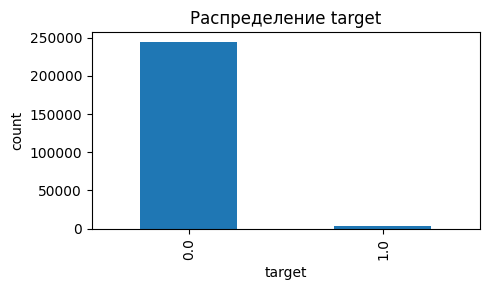

In [4]:
# Распределение target
print("Уникальных значений target:", train[TARGET].nunique())
print()
print(train[TARGET].value_counts(dropna=False))
print()
print(train[TARGET].value_counts(normalize=True, dropna=False).round(4))

plt.figure(figsize=(5, 3))
train[TARGET].value_counts().sort_index().plot(kind="bar")
plt.title("Распределение target")
plt.xlabel("target"); plt.ylabel("count")
plt.tight_layout(); plt.show()

## 3. Типы данных и пропуски
`missing_cnt` и `missing_pct` оставлены на случай появления NaN после будущих преобразований

In [5]:
print(train.dtypes.value_counts())

info_df = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "nunique": train.nunique(dropna=False),
    "missing_cnt": train.isna().sum(),
    "missing_pct": train.isna().mean() * 100,
}).sort_values("nunique")

info_df.head(15)

float64    1361
int64         8
Name: count, dtype: int64


,dtype,nunique,missing_cnt,missing_pct
feature_0,float64,1,0,0.0
feature_1,float64,1,0,0.0
feature_2,float64,1,0,0.0
feature_3,float64,1,0,0.0
feature_1057,float64,1,0,0.0
feature_49,float64,1,0,0.0
feature_1064,float64,1,0,0.0
feature_1366,int64,2,0,0.0
feature_1154,float64,2,0,0.0
feature_1152,float64,2,0,0.0


## 4. Типология признаков
Выделяем группы, которые по-разному обрабатываются при FE:
константные, бинарные, low-cardinality, с `-1`, sparse (много нулей), скошенные, регулярные числовые

In [6]:
# Базовые признаки (без id и target)
base_feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET]]
X_base      = train[base_feature_cols].copy()
X_test_base = test[base_feature_cols].copy()
y           = train[TARGET].copy()

# Константные признаки
constant_cols = [c for c in base_feature_cols if X_base[c].nunique(dropna=False) == 1]

# Рабочий список признаков (без констант)
feature_cols = [c for c in base_feature_cols if c not in constant_cols]

print("Всего базовых признаков:", len(base_feature_cols))
print("Константных            :", len(constant_cols))
print("После удаления констант:", len(feature_cols))
print()
print("Примеры константных:", constant_cols[:10])

Всего базовых признаков: 1367
Константных            : 7
После удаления констант: 1360

Примеры константных: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_49', 'feature_1057', 'feature_1064']


In [7]:
# Группы признаков
binary_cols      = [c for c in feature_cols if X_base[c].nunique(dropna=False) == 2]
low_card_cols    = [c for c in feature_cols if X_base[c].nunique(dropna=False) <= LOW_CARD_MAX_UNIQUE]
minus_one_cols   = [c for c in feature_cols if (X_base[c] == -1).any()]
high_zero_cols   = [c for c in feature_cols if (X_base[c] == 0).mean() >= HIGH_ZERO_MIN_SHARE]

skew_all = X_base[feature_cols].skew()
high_skew_cols = skew_all[skew_all.abs() >= HIGH_SKEW_MIN_ABS].index.tolist()

# Регулярные числовые — то, что не попало ни в одну из "особых" групп
special = set(low_card_cols + minus_one_cols + high_zero_cols + high_skew_cols)
regular_numeric_cols = [c for c in feature_cols if c not in special]

print(f"binary_cols          : {len(binary_cols)}")
print(f"low_card_cols (<= {LOW_CARD_MAX_UNIQUE}): {len(low_card_cols)}")
print(f"minus_one_cols       : {len(minus_one_cols)}")
print(f"high_zero_cols (>= {int(HIGH_ZERO_MIN_SHARE*100)}%): {len(high_zero_cols)}")
print(f"high_skew_cols (|skew|>={HIGH_SKEW_MIN_ABS}): {len(high_skew_cols)}")
print(f"regular_numeric_cols : {len(regular_numeric_cols)}")

binary_cols          : 92
low_card_cols (<= 5): 314
minus_one_cols       : 184
high_zero_cols (>= 80%): 854
high_skew_cols (|skew|>=5.0): 996
regular_numeric_cols : 83


In [8]:
# Описательная статистика и признаки с подозрительным масштабом
desc = X_base[feature_cols].describe().T
desc["range"] = desc["max"] - desc["min"]

# Сортируем по диапазону - на верх всплывают признаки с большими значениями / выбросами
desc.sort_values("range", ascending=False).head(15)

,count,mean,std,min,25%,50%,75%,max,range
feature_829,247972.0,47786.241576,155892.708927,0.0,1809.0,10213.553953,30449.250000,30220726.0,30220726.0
feature_548,247972.0,27821.360976,124581.156032,0.0,0.0,458.000000,7863.000000,30212746.0,30212746.0
feature_743,247972.0,1769.251343,63811.785856,0.0,0.0,0.000000,0.000000,29818625.0,29818625.0
feature_816,247972.0,58045.405927,160786.906525,0.0,3353.0,13230.236903,46493.500000,29694829.0,29694829.0
feature_821,247972.0,58042.644947,160779.217386,0.0,3353.0,13229.387568,46495.750000,29692369.0,29692369.0
feature_1034,247972.0,42082.661408,143727.955332,0.0,1219.0,7523.000000,24515.750000,29684481.0,29684481.0
feature_955,247972.0,137.372371,27196.800978,0.0,0.0,0.000000,0.000000,13414072.0,13414072.0
feature_939,247972.0,1755.614926,25943.927407,0.0,0.0,0.000000,10.000000,8189003.0,8189003.0
feature_547,247972.0,2132.465099,30839.387278,0.0,0.0,0.000000,0.000000,6105214.0,6105214.0
feature_751,247972.0,1457.642221,23563.653919,0.0,0.0,0.000000,0.000000,5067646.0,5067646.0


In [9]:
# Доминирование одного значения
dominance_df = pd.DataFrame({
    "top_value_share": X_base[feature_cols].apply(
        lambda s: s.value_counts(normalize=True, dropna=False).iloc[0]
    ),
    "nunique":        X_base[feature_cols].nunique(dropna=False),
    "zero_pct":       (X_base[feature_cols] == 0).mean() * 100,
    "minus_one_pct":  (X_base[feature_cols] == -1).mean() * 100,
}).sort_values("top_value_share", ascending=False)

dominance_df.head(20)

,top_value_share,nunique,zero_pct,minus_one_pct
feature_1363,0.965258,2,96.525817,0.0
feature_1007,0.903796,2,90.379559,0.0
feature_1061,0.903796,2,90.379559,0.0
feature_987,0.903796,2,90.379559,0.0
feature_667,0.903796,2,90.379559,0.0
feature_698,0.903796,2,90.379559,0.0
feature_697,0.903796,2,90.379559,0.0
feature_549,0.903796,2,90.379559,0.0
feature_688,0.903796,2,90.379559,0.0
feature_536,0.903796,2,90.379559,0.0


## 5. Связь признаков с target
Считаем линейную корреляцию, эффект `-1`, эффект ненулевого значения и бининг для top-признаков

In [10]:
# corrwith работает столбец-к-столбцу, без построения полной матрицы 1367x1367
corr_with_target = X_base[feature_cols].corrwith(y)
corr_with_target_abs = corr_with_target.abs().sort_values(ascending=False)

top_corr_features = corr_with_target_abs.head(TOP_N_FEATURES).index.tolist()

corr_with_target_abs.head(TOP_N_FEATURES).to_frame("abs_corr")

,abs_corr
feature_1094,0.020181
feature_520,0.018198
feature_337,0.017494
feature_525,0.017160
feature_1193,0.016612
feature_890,0.016557
feature_1087,0.015832
feature_4,0.015316
feature_1122,0.015188
feature_1132,0.014610


In [11]:
# Эффект -1 на target rate
rows = []
for col in minus_one_cols:
    is_minus_one = (X_base[col] == -1)
    n = is_minus_one.sum()
    if n == 0:
        continue
    rate_m1   = y[is_minus_one].mean()
    rate_rest = y[~is_minus_one].mean()
    rows.append({
        "feature": col,
        "minus_one_cnt": int(n),
        "minus_one_pct": is_minus_one.mean() * 100,
        "rate_when_m1":  rate_m1,
        "rate_when_not": rate_rest,
        "rate_diff":     rate_m1 - rate_rest,
    })

minus_one_effect_df = pd.DataFrame(rows).sort_values("rate_diff", ascending=False)

# Отмечаем признаки, где -1 информативен
minus_one_effect_df["informative_m1"] = (
    (minus_one_effect_df["minus_one_pct"] >= MINUS_ONE_MIN_PCT) &
    (minus_one_effect_df["rate_diff"].abs() > MINUS_ONE_RATE_DIFF)
)

informative_minus_one_cols = minus_one_effect_df.loc[
    minus_one_effect_df["informative_m1"], "feature"
].tolist()

print("Признаков, где -1 информативен:", len(informative_minus_one_cols))
minus_one_effect_df.head(15)

Признаков, где -1 информативен: 2


,feature,minus_one_cnt,minus_one_pct,rate_when_m1,rate_when_not,rate_diff,informative_m1
15,feature_1119,103241,41.634136,0.014781,0.012575,0.002206,True
18,feature_1123,108703,43.836804,0.014599,0.012630,0.001969,False
11,feature_1115,45462,18.333522,0.014980,0.013160,0.001820,False
17,feature_1121,67627,27.272031,0.014447,0.013136,0.001311,False
5,feature_1109,67627,27.272031,0.014447,0.013136,0.001311,False
16,feature_1120,67627,27.272031,0.014447,0.013136,0.001311,False
19,feature_1124,67755,27.323649,0.014331,0.013179,0.001152,False
8,feature_1112,67755,27.323649,0.014331,0.013179,0.001152,False
13,feature_1117,67755,27.323649,0.014331,0.013179,0.001152,False
9,feature_1113,67782,27.334538,0.014296,0.013192,0.001104,False


In [12]:
# Эффект ненулевого значения (для sparse-признаков)
rows = []
for col in high_zero_cols:
    is_nonzero = (X_base[col] != 0)
    n = is_nonzero.sum()
    if n == 0:
        continue
    rows.append({
        "feature": col,
        "nonzero_pct":   is_nonzero.mean() * 100,
        "rate_nonzero":  y[is_nonzero].mean(),
        "rate_zero":     y[~is_nonzero].mean(),
    })

nonzero_effect_df = pd.DataFrame(rows)
nonzero_effect_df["rate_diff"] = (
    nonzero_effect_df["rate_nonzero"] - nonzero_effect_df["rate_zero"]
)
nonzero_effect_df = nonzero_effect_df.sort_values(
    "rate_diff", key=lambda s: s.abs(), ascending=False
)

nonzero_effect_df.head(15)

,feature,nonzero_pct,rate_nonzero,rate_zero,rate_diff
735,feature_1125,15.197280,0.010375,0.014052,-0.003677
736,feature_1126,15.197280,0.010375,0.014052,-0.003677
745,feature_1181,15.197280,0.010375,0.014052,-0.003677
850,feature_1363,3.474183,0.010679,0.013595,-0.002916
741,feature_1153,15.832433,0.011131,0.013938,-0.002807
742,feature_1154,15.832433,0.011131,0.013938,-0.002807
746,feature_1183,15.832433,0.011131,0.013938,-0.002807
122,feature_270,18.810188,0.015500,0.013028,0.002472
759,feature_1270,19.999032,0.015426,0.013010,0.002415
738,feature_1144,10.919781,0.011375,0.013753,-0.002379


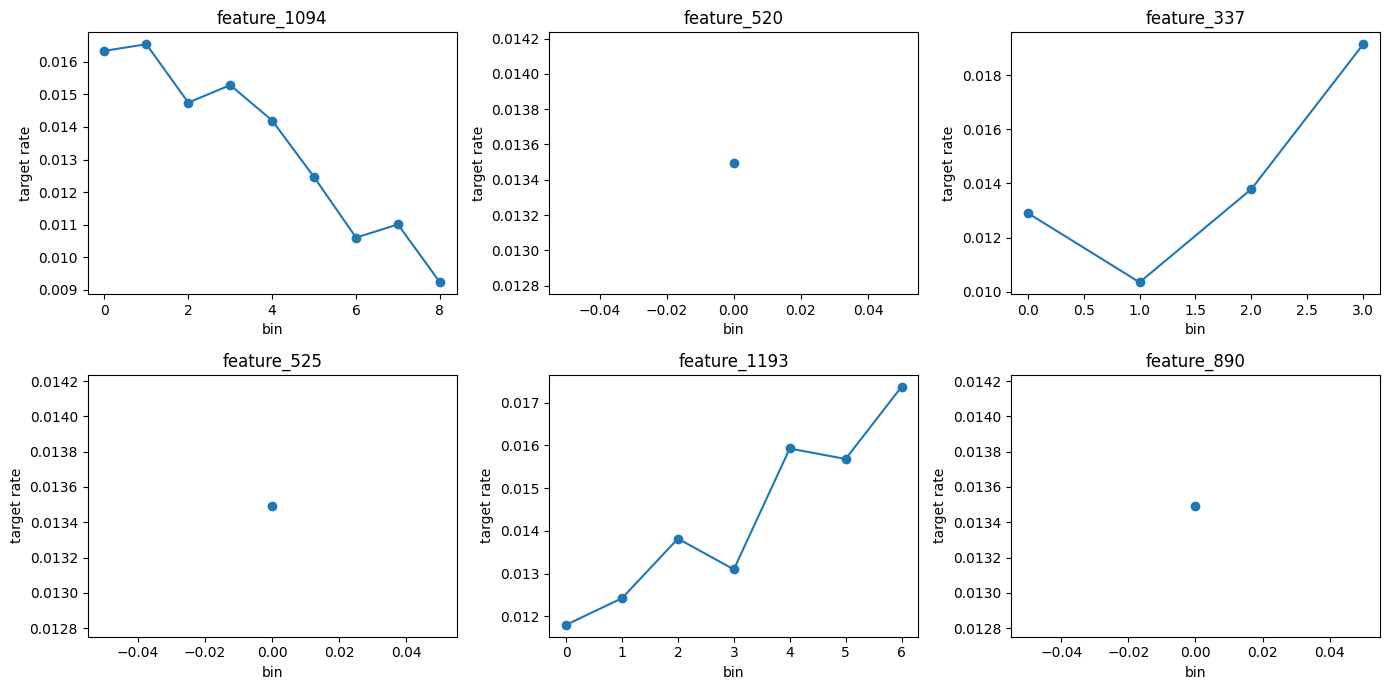

In [ ]:
# Event rate по квантильным бинам для top-признаков
n_plot = min(6, len(top_corr_features))
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(top_corr_features[:n_plot]):
    tmp = pd.DataFrame({"x": X_base[col], "y": y})
    try:
        tmp["bin"] = pd.qcut(tmp["x"], q=10, duplicates="drop")
        stat = tmp.groupby("bin", observed=True)["y"].mean()
        axes[i].plot(range(len(stat)), stat.values, marker="o")
        axes[i].set_title(col)
        axes[i].set_xlabel("bin"); axes[i].set_ylabel("target rate")
    except Exception as e:
        axes[i].set_title(f"{col} (err)")

for j in range(n_plot, len(axes)):
    axes[j].axis("off")

plt.tight_layout(); plt.show()

/var/folders/hk/g8wjnylj3fjddsm0cd35lgp40000gn/T/ipykernel_58304/3571098882.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=sorted(y.unique()), showfliers=False)
/var/folders/hk/g8wjnylj3fjddsm0cd35lgp40000gn/T/ipykernel_58304/3571098882.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=sorted(y.unique()), showfliers=False)
/var/folders/hk/g8wjnylj3fjddsm0cd35lgp40000gn/T/ipykernel_58304/3571098882.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=sorted(y.unique()), showfliers=False)
/var/folders/hk/g8wjnylj3fjddsm0cd35lgp4

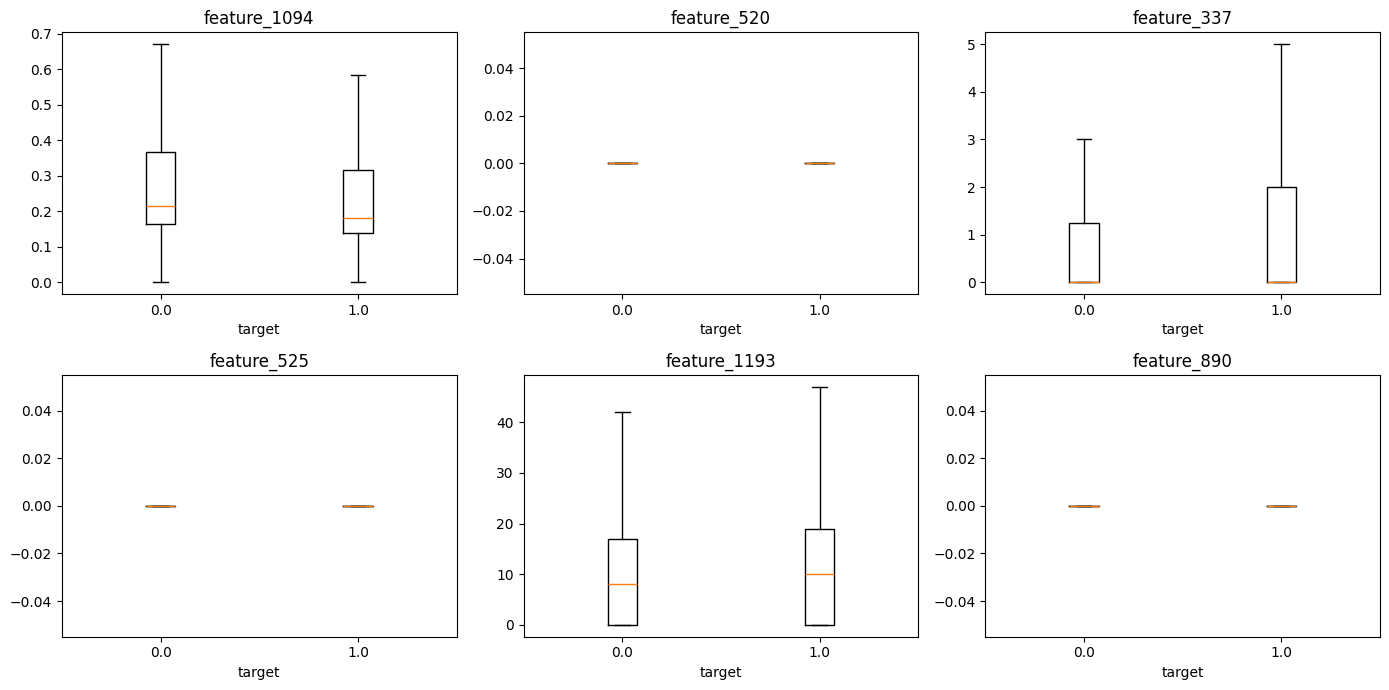

In [14]:
# Boxplot top-признаков в разрезе target (одной сеткой)
n_plot = min(6, len(top_corr_features))
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(top_corr_features[:n_plot]):
    data = [X_base.loc[y == v, col].values for v in sorted(y.unique())]
    axes[i].boxplot(data, labels=sorted(y.unique()), showfliers=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("target")

for j in range(n_plot, len(axes)):
    axes[j].axis("off")

plt.tight_layout(); plt.show()

In [15]:
# Event rate по значениям low-cardinality признаков (первые 10)
for col in low_card_cols[:10]:
    stat = (
        pd.DataFrame({"v": X_base[col], "y": y})
        .groupby("v")["y"]
        .agg(n_obs="count", target_rate="mean")
    )
    print(f"--- {col} ---")
    print(stat)
    print()

--- feature_50 ---
           n_obs  target_rate
v                            
0.000000  214064     0.013389
0.011896   33908     0.014156

--- feature_53 ---
           n_obs  target_rate
v                            
0.000000  214064     0.013389
0.673629   33908     0.014156

--- feature_55 ---
           n_obs  target_rate
v                            
0.000000  214064     0.013389
5.696633   33908     0.014156

--- feature_57 ---
           n_obs  target_rate
v                            
0.000000  214064     0.013389
0.000508   33908     0.014156

--- feature_58 ---
           n_obs  target_rate
v                            
0.000000  214064     0.013389
0.040401   33908     0.014156

--- feature_59 ---
           n_obs  target_rate
v                            
0.000000  214064     0.013389
0.385414   33908     0.014156

--- feature_75 ---
          n_obs  target_rate
v                           
0.00000  214064     0.013389
0.02272   33908     0.014156

--- feature_87 ---
     

## 6. Мультиколлинеарность
Ищем пары признаков с `|corr| >= HIGH_CORR_PAIR_THRESH`
Считаем корреляцию только среди top-признаков, чтобы не строить матрицу на все ~1350 колонок

In [16]:
# Расширяем top до 100 наиболее коррелирующих с target — этого хватит для поиска групп
top_for_corr = corr_with_target_abs.head(100).index.tolist()

corr_matrix = X_base[top_for_corr].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .loc[lambda s: s >= HIGH_CORR_PAIR_THRESH]
    .sort_values(ascending=False)
    .to_frame("abs_corr")
)

print("Пар с |corr| >=", HIGH_CORR_PAIR_THRESH, ":", len(high_corr_pairs))
high_corr_pairs.head(20)

Пар с |corr| >= 0.9 : 31


abs_corr
feature_283  feature_282   0.992870
feature_38   feature_36    0.981028
feature_282  feature_72    0.979782
feature_35   feature_36    0.976587
feature_1139 feature_1141  0.974142
feature_36   feature_14    0.973532
feature_283  feature_72    0.972476
feature_38   feature_35    0.969910
             feature_14    0.966906
feature_35   feature_14    0.962224
feature_40   feature_36    0.957108
feature_15   feature_36    0.952498
feature_40   feature_38    0.951142
feature_15   feature_14    0.949706
feature_40   feature_35    0.949131
feature_1142 feature_1141  0.948376
feature_15   feature_38    0.945750
feature_40   feature_14    0.943976
feature_15   feature_35    0.942956
feature_39   feature_36    0.936980

## 7. Стабильность train vs test
Сравниваем основные статистики между train и test - ищем признаки с распределительным сдвигом

In [17]:
compare_df = pd.DataFrame({
    "train_mean":       X_base.mean(),
    "test_mean":        X_test_base.mean(),
    "train_std":        X_base.std(),
    "test_std":         X_test_base.std(),
    "train_zero_pct":   (X_base == 0).mean() * 100,
    "test_zero_pct":    (X_test_base == 0).mean() * 100,
    "train_minus1_pct": (X_base == -1).mean() * 100,
    "test_minus1_pct":  (X_test_base == -1).mean() * 100,
})
compare_df["mean_diff_abs"]      = (compare_df["train_mean"]       - compare_df["test_mean"]).abs()
compare_df["std_diff_abs"]       = (compare_df["train_std"]        - compare_df["test_std"]).abs()
compare_df["zero_pct_diff_abs"]  = (compare_df["train_zero_pct"]   - compare_df["test_zero_pct"]).abs()
compare_df["minus1_pct_diff_abs"]= (compare_df["train_minus1_pct"] - compare_df["test_minus1_pct"]).abs()

print("Top по сдвигу среднего:")
compare_df.sort_values("mean_diff_abs", ascending=False).head(10)

Top по сдвигу среднего:


,train_mean,test_mean,train_std,test_std,train_zero_pct,test_zero_pct,train_minus1_pct,test_minus1_pct,mean_diff_abs,std_diff_abs,zero_pct_diff_abs,minus1_pct_diff_abs
feature_757,15440.007425,15094.812305,80730.902183,79514.091238,53.885923,53.775147,0.0,0.0,345.195120,1216.810945,0.110775,0.0
feature_548,27821.360976,27560.282848,124581.156032,107373.427393,39.668995,39.692681,0.0,0.0,261.078128,17207.728639,0.023686,0.0
feature_824,7983.251325,7740.516643,26048.509836,24788.236558,7.170164,7.110864,0.0,0.0,242.734682,1260.273278,0.059300,0.0
feature_821,58042.644947,57808.033651,160779.217386,151228.881554,0.007259,0.009410,0.0,0.0,234.611296,9550.335832,0.002151,0.0
feature_816,58045.405927,57811.065778,160786.906525,151234.604751,0.007259,0.009410,0.0,0.0,234.340149,9552.301774,0.002151,0.0
feature_707,2761.345693,2578.267064,19942.379152,18136.299271,40.040811,40.228090,0.0,0.0,183.078629,1806.079881,0.187279,0.0
feature_806,5013.841830,5188.086915,37384.232910,38740.957871,71.661720,71.575362,0.0,0.0,174.245085,1356.724960,0.086358,0.0
feature_749,8206.381898,8310.596748,49105.491637,49729.907403,53.553224,53.657527,0.0,0.0,104.214850,624.415766,0.104303,0.0
feature_912,5865.042305,5966.790368,38817.826463,39152.825531,63.399093,63.354160,0.0,0.0,101.748063,334.999068,0.044933,0.0
feature_751,1457.642221,1364.526869,23563.653919,19194.215654,82.748859,82.854696,0.0,0.0,93.115352,4369.438265,0.105838,0.0


In [18]:
print("Top по сдвигу доли -1:")
compare_df.sort_values("minus1_pct_diff_abs", ascending=False).head(10)

Top по сдвигу доли -1:


,train_mean,test_mean,train_std,test_std,train_zero_pct,test_zero_pct,train_minus1_pct,test_minus1_pct,mean_diff_abs,std_diff_abs,zero_pct_diff_abs,minus1_pct_diff_abs
feature_1113,18.777814,18.895440,12.135384,12.075748,0.0,0.0,27.334538,26.904981,0.117626,0.059635,0.0,0.429556
feature_1121,54.333489,54.651721,33.889981,33.725371,0.0,0.0,27.272031,26.853228,0.318232,0.164610,0.0,0.418802
feature_1120,28.706636,28.882088,18.214614,18.129132,0.0,0.0,27.272031,26.853228,0.175452,0.085483,0.0,0.418802
feature_1109,33.562422,33.763329,21.170133,21.068606,0.0,0.0,27.272031,26.853228,0.200906,0.101526,0.0,0.418802
feature_1112,31.308741,31.479525,19.814970,19.727387,0.0,0.0,27.323649,26.939797,0.170784,0.087582,0.0,0.383852
feature_1124,26.108557,26.253722,16.626471,16.554151,0.0,0.0,27.323649,26.939797,0.145165,0.072320,0.0,0.383852
feature_1117,43.038597,43.237942,27.783343,27.647142,0.0,0.0,27.323649,26.939797,0.199344,0.136201,0.0,0.383852
feature_1123,48.899819,49.241715,44.163614,44.127657,0.0,0.0,43.836804,43.460301,0.341895,0.035957,0.0,0.376503
feature_1119,12.548578,12.618138,11.502597,11.487273,0.0,0.0,41.634136,41.319608,0.069560,0.015324,0.0,0.314528
feature_1111,107.486680,107.992538,96.433128,96.375424,0.0,0.0,44.136031,43.877148,0.505858,0.057704,0.0,0.258884


## 8. Сводная таблица `feature_summary`
Один датафрейм, в котором для каждого признака собрано всё нужное для решений на этапе FE

In [19]:
feature_summary = pd.DataFrame({
    "nunique":         X_base[feature_cols].nunique(),
    "top_value_share": X_base[feature_cols].apply(
        lambda s: s.value_counts(normalize=True, dropna=False).iloc[0]
    ),
    "zero_pct":        (X_base[feature_cols] == 0).mean() * 100,
    "minus_one_pct":   (X_base[feature_cols] == -1).mean() * 100,
    "skew":            X_base[feature_cols].skew(),
    "abs_corr_target": corr_with_target_abs,
    "mean_diff_tt":    compare_df["mean_diff_abs"],
    "minus1_diff_tt":  compare_df["minus1_pct_diff_abs"],
})

# Флаги групп
feature_summary["is_binary"]      = feature_summary.index.isin(binary_cols)
feature_summary["is_low_card"]    = feature_summary.index.isin(low_card_cols)
feature_summary["has_minus_one"]  = feature_summary.index.isin(minus_one_cols)
feature_summary["is_high_zero"]   = feature_summary.index.isin(high_zero_cols)
feature_summary["is_high_skew"]   = feature_summary.index.isin(high_skew_cols)
feature_summary["is_regular"]     = feature_summary.index.isin(regular_numeric_cols)
feature_summary["informative_m1"] = feature_summary.index.isin(informative_minus_one_cols)

feature_summary = feature_summary.sort_values("abs_corr_target", ascending=False)
feature_summary.head(20)

,nunique,top_value_share,zero_pct,minus_one_pct,skew,abs_corr_target,mean_diff_tt,minus1_diff_tt,is_binary,is_low_card,has_minus_one,is_high_zero,is_high_skew,is_regular,informative_m1
feature_1094,203562.0,0.153082,0.000000,0.000000,0.895979,0.020181,0.000211,0.000000,False,False,False,False,False,True,False
feature_520,10.0,0.903763,90.376333,0.000000,456.764803,0.018198,0.001216,0.000000,False,False,False,True,True,False,False
feature_337,603.0,0.618751,61.875131,0.000000,17.724051,0.017494,0.088760,0.000000,False,False,False,False,True,False,False
feature_525,3.0,0.903792,90.379156,0.000000,497.786206,0.017160,0.000569,0.000000,False,True,False,True,True,False,False
feature_1193,65.0,0.323783,32.378252,0.000000,0.808906,0.016612,0.058685,0.000000,False,False,False,False,False,True,False
feature_890,86.0,0.903412,90.341248,0.000000,462.458416,0.016557,1.378796,0.000000,False,False,False,True,True,False,False
feature_1087,201680.0,0.160268,0.000000,0.000000,0.841002,0.015832,0.000095,0.000000,False,False,False,False,False,True,False
feature_4,13.0,0.532379,34.848289,0.000000,1.070933,0.015316,0.002548,0.000000,False,False,False,False,False,True,False
feature_1122,2788.0,0.041908,0.000000,0.000000,0.512887,0.015188,0.000082,0.000000,False,False,False,False,False,True,False
feature_1132,2.0,0.666757,66.675673,0.000000,0.707541,0.014610,0.000573,0.000000,True,True,False,False,False,False,False


## 9. Cleaning
Готовим две версии данных:
- **v1**: `-1` сохраняется как есть (базовая версия для baseline)
- **v2**: `-1` заменяется на `NaN` (альтернатива, проверить на baseline позже)

In [20]:
# v1 — без изменений значений, только без констант
X_clean_v1      = X_base[feature_cols].copy()
X_test_clean_v1 = X_test_base[feature_cols].copy()

# v2 — с -1 -> NaN
X_clean_v2      = X_clean_v1.copy()
X_test_clean_v2 = X_test_clean_v1.copy()
X_clean_v2[minus_one_cols]      = X_clean_v2[minus_one_cols].replace(-1, np.nan)
X_test_clean_v2[minus_one_cols] = X_test_clean_v2[minus_one_cols].replace(-1, np.nan)

print("v1:", X_clean_v1.shape, "| test:", X_test_clean_v1.shape)
print("v2:", X_clean_v2.shape, "| test:", X_test_clean_v2.shape)
print("NaN в v2 (train):", int(X_clean_v2.isna().sum().sum()))
print("NaN в v2 (test) :", int(X_test_clean_v2.isna().sum().sum()))

v1: (247972, 1360) | test: (106274, 1360)
v2: (247972, 1360) | test: (106274, 1360)
NaN в v2 (train): 7369026
NaN в v2 (test) : 3110887


## 10. Сохранение артефактов
Эти файлы читаются в следующем ноутбуке с Feature Engineering - никаких повторных расчётов `constant_cols`, `minus_one_cols` и т.п. не потребуется

In [23]:
!pip install fastparquet

# Датасеты
X_clean_v1.to_parquet(ARTIFACTS_DIR / "X_train_v1.parquet")
X_test_clean_v1.to_parquet(ARTIFACTS_DIR / "X_test_v1.parquet")
X_clean_v2.to_parquet(ARTIFACTS_DIR / "X_train_v2.parquet")
X_test_clean_v2.to_parquet(ARTIFACTS_DIR / "X_test_v2.parquet")
y.to_frame().to_parquet(ARTIFACTS_DIR / "y_train.parquet")

# ID'ы (пригодятся для submission)
train[[ID_COL]].to_parquet(ARTIFACTS_DIR / "train_ids.parquet")
test[[ID_COL]].to_parquet(ARTIFACTS_DIR / "test_ids.parquet")

# Группы признаков
feature_groups = {
    "constant":         constant_cols,
    "binary":           binary_cols,
    "low_cardinality":  low_card_cols,
    "minus_one":        minus_one_cols,
    "informative_m1":   informative_minus_one_cols,
    "high_zero":        high_zero_cols,
    "high_skew":        high_skew_cols,
    "regular_numeric":  regular_numeric_cols,
    "top_corr":         top_corr_features,
    "high_corr_pairs":  high_corr_pairs.reset_index().values.tolist(),
}
with open(ARTIFACTS_DIR / "feature_groups.pkl", "wb") as f:
    pickle.dump(feature_groups, f)

# Сводные таблицы
feature_summary.to_parquet(ARTIFACTS_DIR / "feature_summary.parquet")
minus_one_effect_df.to_parquet(ARTIFACTS_DIR / "minus_one_effect.parquet")
nonzero_effect_df.to_parquet(ARTIFACTS_DIR / "nonzero_effect.parquet")
compare_df.to_parquet(ARTIFACTS_DIR / "train_test_compare.parquet")

print("Сохранено в:", ARTIFACTS_DIR.resolve())
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print(" -", p.name)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 896.9/896.9 kB 6.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fastparquet]
Сохранено в: /Users/davidkk/Downloads/vk-predict-cmc-hackathon/artifacts
 - X_test_v1.parquet
 - X_test_v2.parquet
 - X_train_v1.parquet
 - X_train_v2.parquet
 - feature_groups.pkl
 - feature_summary.parquet
 - minus_one_effect.parquet
 - nonzero_effect.parquet
 - test_ids.parquet
 - train_ids.parquet
 - train_test_compare.parquet
 - y_train.parquet


## Финальные правила очистки данных перед baseline

1. `index` исключён из признаков, сохранён отдельно как идентификатор
2. `target` отделён от матрицы признаков
3. Константные признаки удалены из train и test
4. Sparse и low-cardinality признаки **не удаляются автоматически**: часть из них показывает значимый эффект на target (см. `nonzero_effect_df` и таблицу по low-card в разделе 5)
5. Признаки с `-1` сохранены как есть в **v1**; распределение `-1` стабильно между train и test (см. `compare_df`)
6. Версия **v2** с `-1 → NaN` сохранена как альтернатива для сравнения на baseline
7. Агрессивное удаление скоррелированных признаков на этом этапе **не применяется**: список пар `high_corr_pairs` сохранён, решение принимается после baseline по feature importance

## Что делать в Feature Engineering

Всё уже подготовлено, достаточно прочитать артефакты:

```python
X = pd.read_parquet("artifacts/X_train_v1.parquet")
y = pd.read_parquet("artifacts/y_train.parquet")["target"]
with open("artifacts/feature_groups.pkl", "rb") as f:
    groups = pickle.load(f)
summary = pd.read_parquet("artifacts/feature_summary.parquet")
```

Направления для FE:
- бинаризация `is_minus_one` для признаков из `informative_m1`
- бинаризация `is_nonzero` для признаков из `high_zero` с сильным `rate_diff` в `nonzero_effect_df`
- логарифмирование / winsorization для `high_skew`
- агрегации / PCA по группам скоррелированных признаков из `high_corr_pairs`
- target encoding для `low_cardinality`
